In [1]:
import sys
from pathlib import Path
import yaml

import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.model.regression_dataset import create_regression_dataloaders

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

Data for regression is stored in data/processed/regression_dataset.parquet.
- Data for nutrient profiles is stored in data/processed/exp_nutrient_onehot.json.
    - formatted with an orgId, expName, nutrient_name(1-530) 
- Data for ProteomeLM embeddings is stored in data/processed/ProtLM_embeddings_layer8
    - Contains pt files, one for each organism. Use torch.load to load in dictionary objects with the following keys: embeddings and group_labels (corresponds to gene_key column in regression_dataset) 


In [2]:
train_loader, val_loader, test_loader = create_regression_dataloaders(
    batch_size=2048,
    num_workers=2, 
    subset="processed"
)

x, y = next(iter(train_loader))
print(x.shape)
print(y.shape)



torch.Size([2048, 1682])
torch.Size([2048, 1])


In [3]:
# Minimal MLP: one hidden layer. No dropout, no class weights, no project code.
# input dim is 1152 length PLM embedding + 530 length nutrient profile (one-hot)
input_dim = 1682
hidden_dim_1 = 2048
hidden_dim_2 = 512
dropout_rate = 0.3
learning_rate = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim_1),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(hidden_dim_1, hidden_dim_2),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(hidden_dim_2, 1),
).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [4]:
# Two-tower: gene embedding tower + nutrient tower, then concat and predict.
# Same dataloader: x is [B, 1682]; we slice in the model (first 1152 = gene, last 530 = nutrient).

EMBED_DIM = 1152
NUTRIENT_DIM = 530


class TwoTowerRegression(nn.Module):
    def __init__(
        self,
        gene_hidden: int = 256,
        nutrient_hidden: int = 128,
        merge_hidden: int = 256,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.gene_tower = nn.Sequential(
            nn.Linear(EMBED_DIM, gene_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.nutrient_tower = nn.Sequential(
            nn.Linear(NUTRIENT_DIM, nutrient_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.merge = nn.Sequential(
            nn.Linear(gene_hidden + nutrient_hidden, merge_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(merge_hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gene = x[:, :EMBED_DIM]
        nutrient = x[:, EMBED_DIM:]
        gene_out = self.gene_tower(gene)
        nutrient_out = self.nutrient_tower(nutrient)
        combined = torch.cat([gene_out, nutrient_out], dim=1)
        return self.merge(combined)


# Use this instead of the Sequential above to train the two-tower model.
# (Run the cell above first for device, learning_rate, dropout_rate.)
model = TwoTowerRegression(
    gene_hidden=256,
    nutrient_hidden=128,
    merge_hidden=256,
    dropout=dropout_rate,
).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [5]:
train_loss, val_loss = [], []

epochs = 3
for epoch in range(epochs):
    model.train()
    train_total = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_total+= loss.item()
    mean_train = train_total / len(train_loader)
    train_loss.append(mean_train)
    
    # validation
    model.eval()
    val_total = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_total += loss_fn(model(x), y).item()
    mean_val = val_total / len(val_loader)
    val_loss.append(mean_val)

    print(f"Epoch {epoch+4}/{epochs+3}")
    print(f"Train Loss: {mean_train:.4f}, Val Loss: {mean_val:.4f}")
    print()




Epoch 4/6
Train Loss: 0.2546, Val Loss: 0.3404

Epoch 5/6
Train Loss: 0.2301, Val Loss: 0.3415

Epoch 6/6
Train Loss: 0.2229, Val Loss: 0.3477



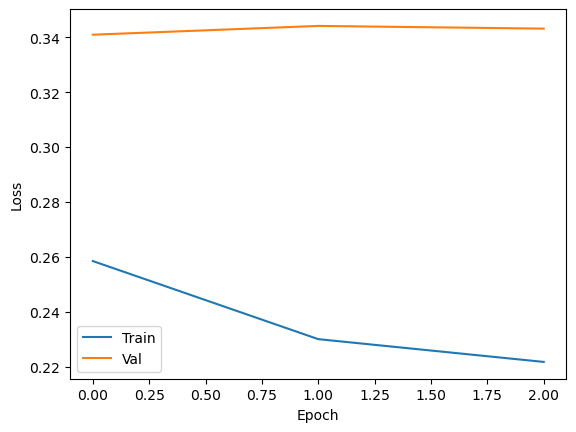

In [5]:
# Plot train vs val loss
import matplotlib.pyplot as plt
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

***
Two-Tower approach